# Task 6 Notebook: Cross-Validation & Ablation

This notebook is designed by **Thandeka**.

It uses the latest group files and keeps the whole exercise in Jupyter.

## What this notebook does

1. Loads the week 2, 4, 6, and 8 processed feature tables.
2. Loads the Task 4 baseline results, if available.
3. Loads the saved model inspection summary, if available.
4. Re-runs the official Task 4 baseline model families using 5-fold stratified CV
   **with per-fold F1-optimal threshold selection** (matched to OULAD_Team_4.ipynb).
5. Runs Task 6 feature-drop ablation (threshold-aware).
6. Runs Task 6 encoding ablation (threshold-aware).
7. Runs advanced / Task 5-style model CV by recreating the model definitions inside CV folds.
8. Produces report-ready CSV tables and PNG figures.

> **Threshold consistency** — every CV fold selects its own F1-optimal threshold
> on a 20 % held-out portion of the training fold (using `select_best_threshold()`
> ported from `OULAD_Team_4.ipynb`). The reported metrics and `threshold` column
> in all tables now reflect this optimised threshold, not a fixed 0.5 cut-off.


## 1. Imports and global settings

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

try:
    from sklearn.calibration import CalibratedClassifierCV
    HAS_CALIBRATION = True
except Exception:
    HAS_CALIBRATION = False

try:
    from sklearn.preprocessing import TargetEncoder
    HAS_TARGET_ENCODER = True
except Exception:
    HAS_TARGET_ENCODER = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
CV_FOLDS = 5

WEEKS = ["week2", "week4", "week6", "week8"]
WEEK_NUM = {"week2": 2, "week4": 4, "week6": 6, "week8": 8}

TARGET = "label"
ID_COLS = ["id_student", "code_module", "code_presentation"]

DEMO_CAT_COLS = ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]
DEMO_NUM_COLS = ["num_of_prev_attempts", "studied_credits"]

VLE_ACT_TYPES = [
    "oucontent", "quiz", "resource", "homepage",
    "subpage", "glossary", "oucollaborate", "forumng",
]

# This is False to align with the latest Task 4 script, which drops
# id_student, code_module, and code_presentation before modelling.

INCLUDE_MODULE_PRESENTATION_AS_FEATURES = False

Path("results").mkdir(exist_ok=True)

print("XGBoost available:", HAS_XGBOOST)
print("CatBoost available:", HAS_CATBOOST)
print("TargetEncoder available:", HAS_TARGET_ENCODER)


XGBoost available: True
CatBoost available: True
TargetEncoder available: True


## 2. Locate project files

In [2]:
def first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None

def find_feature_file(week: str) -> Path:
    candidates = [
        Path("data") / "processed" / f"{week}_features.csv",
        Path(f"{week}_features.csv"),
        Path("processed") / f"{week}_features.csv",
    ]
    path = first_existing(candidates)
    if path is None:
        raise FileNotFoundError(f"Could not find {week}_features.csv")
    return path

task4_results_path = first_existing([
    "data/processed/task4_baseline_results.csv",
    "task4_baseline_results.csv",
])

model_inspection_path = first_existing([
    "data/processed/model_inspection_summary.csv",
    "model_inspection_summary.csv",
])

print("Task 4 results:", task4_results_path)
print("Model inspection summary:", model_inspection_path)

for week in WEEKS:
    print(week, "->", find_feature_file(week))


Task 4 results: data\processed\task4_baseline_results.csv
Model inspection summary: data\processed\model_inspection_summary.csv
week2 -> data\processed\week2_features.csv
week4 -> data\processed\week4_features.csv
week6 -> data\processed\week6_features.csv
week8 -> data\processed\week8_features.csv


## 3. Load the week feature tables

In [3]:
def load_week_df(week: str) -> pd.DataFrame:
    df = pd.read_csv(find_feature_file(week))
    if TARGET not in df.columns:
        raise ValueError(f"{week} file does not contain target column: {TARGET}")
    return df

def split_xy(df: pd.DataFrame):
    drop_cols = [TARGET, "id_student"]
    if not INCLUDE_MODULE_PRESENTATION_AS_FEATURES:
        drop_cols += ["code_module", "code_presentation"]
    drop_cols = [c for c in drop_cols if c in df.columns]

    X = df.drop(columns=drop_cols)
    y = df[TARGET].astype(int)
    return X, y

summary_rows = []
for week in WEEKS:
    df = load_week_df(week)
    X, y = split_xy(df)
    summary_rows.append({
        "week": week,
        "rows": len(df),
        "features_used": X.shape[1],
        "favourable_1": int((y == 1).sum()),
        "unfavourable_0": int((y == 0).sum()),
        "unfavourable_%": round((y == 0).mean() * 100, 2),
    })

data_summary = pd.DataFrame(summary_rows)
data_summary


,week,rows,features_used,favourable_1,unfavourable_0,unfavourable_%
0,week2,32593,18,15385,17208,52.8
1,week4,32593,18,15385,17208,52.8
2,week6,32593,18,15385,17208,52.8
3,week8,32593,18,15385,17208,52.8


## 3B. Exploratory Data Analysis figures

This section adds EDA figures before modelling. These figures help verify the processed week-cutoff datasets and give the report team visual evidence of class balance, VLE engagement over time, missingness, and simple target relationships.


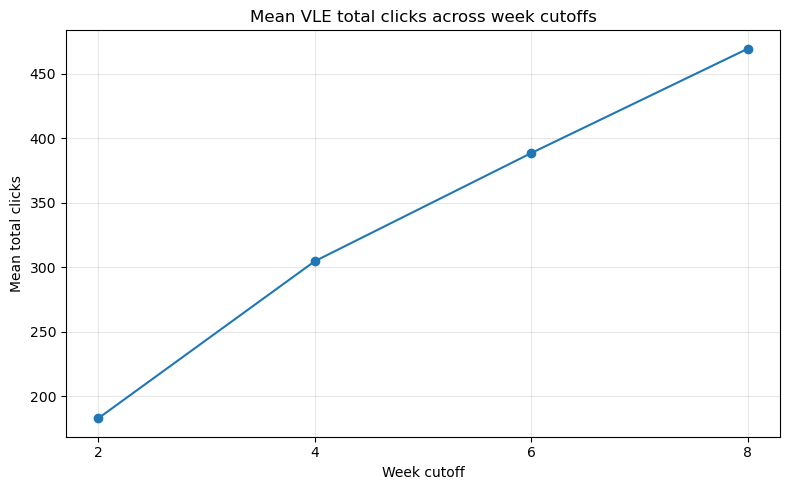

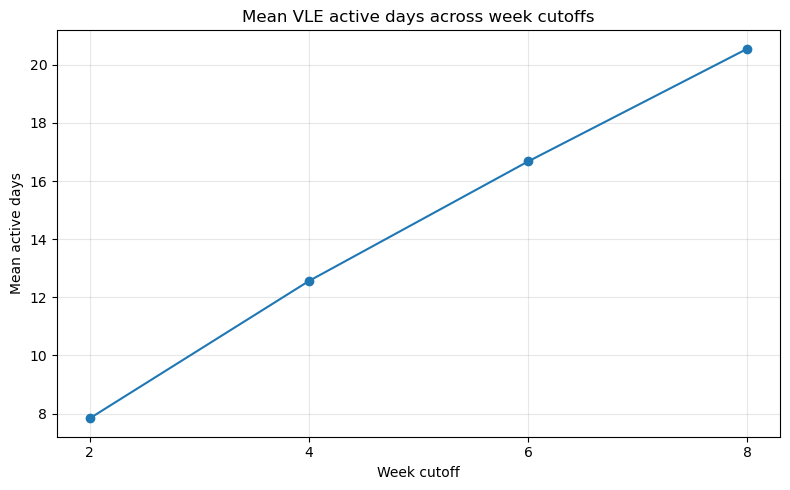

Saved: results/eda_mean_total_clicks_by_week.png
Saved: results/eda_mean_active_days_by_week.png
Saved: results/eda_vle_engagement_summary.csv


,week,mean_total_clicks,mean_active_days
0,2,182.820606,7.839505
1,4,304.646703,12.563280
2,6,388.536956,16.676219
3,8,469.476084,20.552757


In [4]:
# EDA Figure 1: Mean VLE engagement by week
vle_summary_rows = []

for week in WEEKS:
    df = load_week_df(week)
    total_col = f"total_clicks_{week}"
    active_col = f"active_days_{week}"

    vle_summary_rows.append({
        "week": WEEK_NUM[week],
        "mean_total_clicks": float(df[total_col].mean()) if total_col in df.columns else np.nan,
        "mean_active_days": float(df[active_col].mean()) if active_col in df.columns else np.nan,
    })

vle_summary = pd.DataFrame(vle_summary_rows).sort_values("week")

plt.figure(figsize=(8, 5))
plt.plot(vle_summary["week"], vle_summary["mean_total_clicks"], marker="o")
plt.xlabel("Week cutoff")
plt.ylabel("Mean total clicks")
plt.title("Mean VLE total clicks across week cutoffs")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/eda_mean_total_clicks_by_week.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(vle_summary["week"], vle_summary["mean_active_days"], marker="o")
plt.xlabel("Week cutoff")
plt.ylabel("Mean active days")
plt.title("Mean VLE active days across week cutoffs")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/eda_mean_active_days_by_week.png", dpi=200)
plt.show()

vle_summary.to_csv("results/eda_vle_engagement_summary.csv", index=False)
print("Saved: results/eda_mean_total_clicks_by_week.png")
print("Saved: results/eda_mean_active_days_by_week.png")
print("Saved: results/eda_vle_engagement_summary.csv")
vle_summary


In [5]:
# EDA table: Missing-value columns in Week 

Path("results").mkdir(exist_ok=True)

week_for_missing = "week4"
df_missing = load_week_df(week_for_missing)

missing_percent = (
    df_missing.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

top_missing = missing_percent[missing_percent > 0].head(15)

if len(top_missing) == 0:
    print(f"No missing values found in {week_for_missing}.")
    top_missing_df = pd.DataFrame(columns=["feature", "missing_percent"])
else:
    top_missing_df = top_missing.reset_index()
    top_missing_df.columns = ["feature", "missing_percent"]

top_missing_df.to_csv("results/eda_week4_missing_values.csv", index=False)

print("Saved: results/eda_week4_missing_values.csv")
top_missing_df


Saved: results/eda_week4_missing_values.csv


,feature,missing_percent
0,imd_band,3.408707


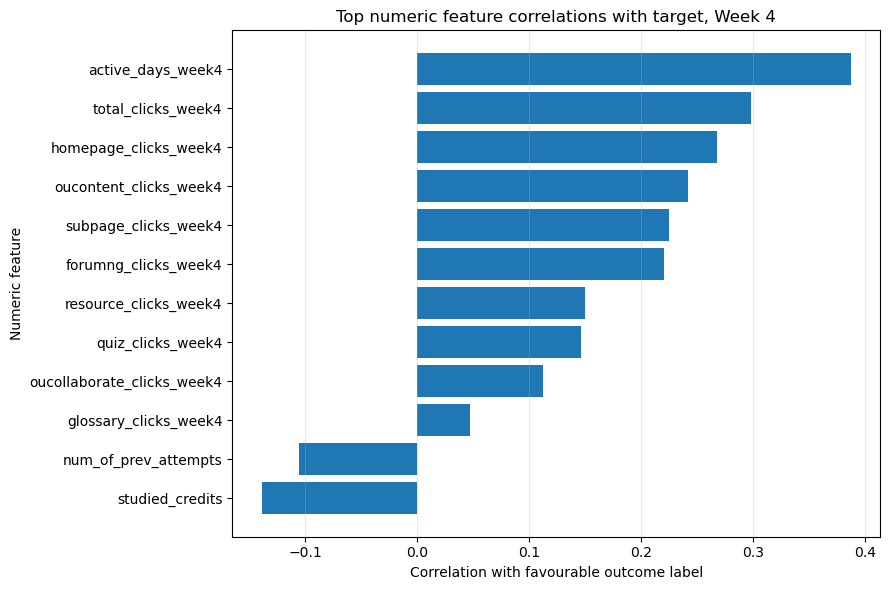

Saved: results/eda_week4_numeric_correlations.png
Saved: results/eda_week4_numeric_correlations.csv


,feature,correlation_with_label,absolute_correlation
3,active_days_week4,0.387156,0.387156
2,total_clicks_week4,0.298202,0.298202
7,homepage_clicks_week4,0.268266,0.268266
4,oucontent_clicks_week4,0.241793,0.241793
8,subpage_clicks_week4,0.225327,0.225327
11,forumng_clicks_week4,0.220593,0.220593
6,resource_clicks_week4,0.150181,0.150181
5,quiz_clicks_week4,0.146117,0.146117
1,studied_credits,-0.138630,0.138630
10,oucollaborate_clicks_week4,0.112783,0.112783


In [6]:
# EDA Figure 3: Numeric feature correlation with target in Week 4
week_for_corr = "week4"
df_corr = load_week_df(week_for_corr)
X_corr, y_corr = split_xy(df_corr)

numeric_cols = X_corr.select_dtypes(include=["int64", "int32", "float64", "float32", "Int64"]).columns.tolist()

corr_rows = []
for col in numeric_cols:
    series = X_corr[col]
    if series.nunique(dropna=True) > 1:
        corr_value = series.corr(y_corr)
        if pd.notna(corr_value):
            corr_rows.append({
                "feature": col,
                "correlation_with_label": float(corr_value),
                "absolute_correlation": float(abs(corr_value)),
            })

corr_df = (
    pd.DataFrame(corr_rows)
    .sort_values("absolute_correlation", ascending=False)
    .head(15)
)

if len(corr_df) == 0:
    print("No numeric correlations available.")
else:
    plot_df = corr_df.sort_values("correlation_with_label")
    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["feature"], plot_df["correlation_with_label"])
    plt.xlabel("Correlation with favourable outcome label")
    plt.ylabel("Numeric feature")
    plt.title("Top numeric feature correlations with target, Week 4")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/eda_week4_numeric_correlations.png", dpi=200)
    plt.show()
    print("Saved: results/eda_week4_numeric_correlations.png")

corr_df.to_csv("results/eda_week4_numeric_correlations.csv", index=False)
print("Saved: results/eda_week4_numeric_correlations.csv")
corr_df


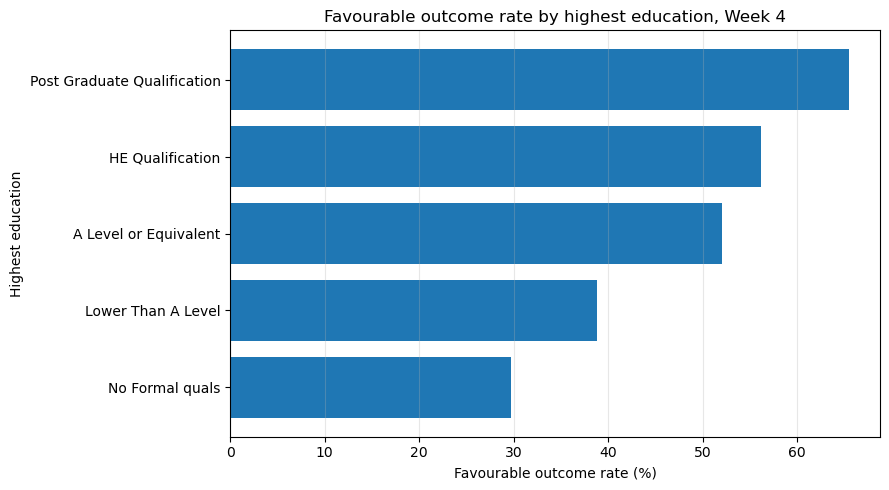

Saved: results/eda_week4_highest_education_outcome_rate.png
Saved: results/eda_week4_highest_education_outcome_rate.csv


,highest_education,favourable_rate_percent
0,No Formal quals,29.682997
1,Lower Than A Level,38.850889
2,A Level or Equivalent,52.032752
3,HE Qualification,56.173362
4,Post Graduate Qualification,65.495208


In [7]:
# EDA Figure 4: Favourable outcome rate by highest education, if available
week_for_category = "week4"
df_cat = load_week_df(week_for_category)

if "highest_education" not in df_cat.columns:
    print("highest_education column not found, skipping this EDA figure.")
else:
    edu_rate = (
        df_cat
        .groupby("highest_education")[TARGET]
        .mean()
        .sort_values()
        .mul(100)
        .reset_index()
    )
    edu_rate.columns = ["highest_education", "favourable_rate_percent"]

    plt.figure(figsize=(9, 5))
    plt.barh(edu_rate["highest_education"], edu_rate["favourable_rate_percent"])
    plt.xlabel("Favourable outcome rate (%)")
    plt.ylabel("Highest education")
    plt.title("Favourable outcome rate by highest education, Week 4")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/eda_week4_highest_education_outcome_rate.png", dpi=200)
    plt.show()

    edu_rate.to_csv("results/eda_week4_highest_education_outcome_rate.csv", index=False)
    print("Saved: results/eda_week4_highest_education_outcome_rate.png")
    print("Saved: results/eda_week4_highest_education_outcome_rate.csv")
    display(edu_rate)


## 4. View Task 4 baseline results and saved model inspection

In [8]:
if task4_results_path is not None:
    task4_baseline_results = pd.read_csv(task4_results_path)
    display(task4_baseline_results.head())
else:
    task4_baseline_results = None
    print("No Task 4 results CSV found.")

if model_inspection_path is not None:
    model_inspection = pd.read_csv(model_inspection_path)
    display(model_inspection[[
        "file", "loaded_successfully", "object_type", "is_pipeline",
        "pipeline_steps", "has_predict", "has_predict_proba", "n_features_in", "load_error"
    ]])
else:
    model_inspection = None
    print("No model inspection summary found.")


,Run ID,Week cutoff,Feature table,Model,Class taught baseline,Self-learnt method,Preprocessing,Evaluation method,Seed,Threshold,...,Precision,Recall,Specificity,F1,AUC,Log loss,TN,FP,FN,TP
0,W2_B1_LogisticRegression,2,week2_features.csv,B1_LogisticRegression,Yes,No,SimpleImputer + OneHotEncoder + StandardScaler,80/20 stratified split,42,0.5,...,0.698190,0.614235,0.762638,0.653527,0.759659,0.587224,2625,817,1187,1890
1,W2_B2_L1_Regularised_LogisticRegression,2,week2_features.csv,B2_L1_Regularised_LogisticRegression,Yes,No,SimpleImputer + OneHotEncoder + StandardScaler,80/20 stratified split,42,0.5,...,0.697709,0.613585,0.762347,0.652948,0.759769,0.587196,2624,818,1189,1888
2,W2_B3_SGD_Logistic,2,week2_features.csv,B3_SGD_Logistic,Yes,No,SimpleImputer + OneHotEncoder + StandardScaler,80/20 stratified split,42,0.5,...,0.683168,0.627884,0.739686,0.654361,0.751020,0.594325,2546,896,1145,1932
3,W2_B4_KNN,2,week2_features.csv,B4_KNN,Yes,No,SimpleImputer + OneHotEncoder + StandardScaler,80/20 stratified split,42,0.5,...,0.665878,0.640559,0.712667,0.652973,0.744327,0.682376,2453,989,1106,1971
4,W2_B5_GaussianNB,2,week2_features.csv,B5_GaussianNB,Yes,No,SimpleImputer + OneHotEncoder + StandardScaler,80/20 stratified split,42,0.5,...,0.731441,0.326617,0.892795,0.451584,0.709280,2.514678,3073,369,2072,1005


,file,loaded_successfully,object_type,is_pipeline,pipeline_steps,has_predict,has_predict_proba,n_features_in,load_error
0,pipeline_1_rf_calibrated.pkl,True,<class 'sklearn.pipeline.Pipeline'>,True,preprocessor: ColumnTransformer | classifier: ...,True,True,8.0,NaN
1,pipeline_2_gbm.pkl,True,<class 'sklearn.pipeline.Pipeline'>,True,preprocessor: ColumnTransformer | classifier: ...,True,True,8.0,NaN
2,pipeline_3_logreg_weighted_balanced.pkl,True,<class 'sklearn.pipeline.Pipeline'>,True,preprocessor: ColumnTransformer | model: Logis...,True,True,18.0,NaN
3,pipeline_4_rf_model-weighted_balance.pkl,True,<class 'sklearn.pipeline.Pipeline'>,True,scaler: StandardScaler | model: RandomForestCl...,True,True,19.0,NaN
4,pipeline_5_catboost.pkl,True,<class 'dict'>,False,NaN,False,False,NaN,NaN
5,pipeline_6_knn.pkl,True,<class 'sklearn.pipeline.Pipeline'>,True,preprocessor: ColumnTransformer | classifier: ...,True,True,6.0,NaN
6,pipeline_7_xgboost.pkl,True,<class 'sklearn.pipeline.Pipeline'>,True,preprocessor: ColumnTransformer | classifier: ...,True,True,6.0,NaN


## 5. Modelling helper functions

These helpers keep preprocessing inside the sklearn pipeline, so imputation, encoding, and scaling are fitted only on the training fold during CV.


In [9]:
def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_bagging_logreg():
    base_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    try:
        return BaggingClassifier(
            estimator=base_model,
            n_estimators=10,
            random_state=RANDOM_STATE,
        )
    except TypeError:
        return BaggingClassifier(
            base_estimator=base_model,
            n_estimators=10,
            random_state=RANDOM_STATE,
        )

def infer_columns(X: pd.DataFrame):
    categorical_cols = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=["int64", "int32", "float64", "float32", "Int64"]).columns.tolist()
    return categorical_cols, numeric_cols

def build_onehot_preprocessor(X: pd.DataFrame, scale_numeric=True):
    categorical_cols, numeric_cols = infer_columns(X)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder()),
    ])

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    transformers = []
    if categorical_cols:
        transformers.append(("cat", categorical_pipeline, categorical_cols))
    if numeric_cols:
        transformers.append(("num", numeric_pipeline, numeric_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

def build_ordinal_preprocessor(X: pd.DataFrame, scale_numeric=True):
    categorical_cols, numeric_cols = infer_columns(X)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    transformers = []
    if categorical_cols:
        transformers.append(("cat", categorical_pipeline, categorical_cols))
    if numeric_cols:
        transformers.append(("num", numeric_pipeline, numeric_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

def build_target_preprocessor(X: pd.DataFrame, scale_numeric=True):
    if not HAS_TARGET_ENCODER:
        raise RuntimeError("TargetEncoder is not available in this sklearn version.")

    categorical_cols, numeric_cols = infer_columns(X)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target", TargetEncoder(random_state=RANDOM_STATE)),
    ])

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    transformers = []
    if categorical_cols:
        transformers.append(("cat", categorical_pipeline, categorical_cols))
    if numeric_cols:
        transformers.append(("num", numeric_pipeline, numeric_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc",
}

def select_best_threshold(y_true, probabilities):
    """Find the classification threshold that maximises F1 on validation data.
    
    Ported from OULAD_Team_4.ipynb so that task6 uses the same threshold logic
    as the main benchmark notebook.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    if thresholds.size == 0:
        threshold = 0.5
        f1_val = f1_score(y_true, (probabilities >= threshold).astype(int),
                          zero_division=0)
        return float(threshold), float(f1_val)
    numerator   = 2 * precision[:-1] * recall[:-1]
    denominator = np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    f1_scores   = numerator / denominator
    best_idx    = int(np.nanargmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def evaluate_pipeline_cv(X, y, pipeline, cv):
    """5-fold stratified CV with per-fold F1-optimal threshold selection.

    For each fold:
      1. Hold out 20 % of the training fold to select the best-F1 threshold.
      2. Fit on the remaining 80 %.
      3. Evaluate on the test fold using that threshold.

    This matches the threshold logic in OULAD_Team_4.ipynb so that every
    reported metric — accuracy, precision, recall, F1, AUC — is computed at
    the same optimised threshold, not a fixed 0.5 cut-off.
    """
    fold_records = []
    for train_idx, test_idx in cv.split(X, y):
        X_tr_full = X.iloc[train_idx]
        y_tr_full = y.iloc[train_idx]
        X_te      = X.iloc[test_idx]
        y_te      = y.iloc[test_idx]

        # Hold out 20 % of training for threshold selection only
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tr_full, y_tr_full,
            test_size=0.20,
            random_state=RANDOM_STATE,
            stratify=y_tr_full,
        )

        pipe = clone(pipeline)
        pipe.fit(X_tr, y_tr)

        # Select threshold on the held-out validation portion
        val_probs         = pipe.predict_proba(X_val)[:, 1]
        threshold, _      = select_best_threshold(y_val, val_probs)

        # Evaluate on the test fold
        test_probs  = pipe.predict_proba(X_te)[:, 1]
        test_preds  = (test_probs >= threshold).astype(int)

        fold_records.append({
            "accuracy":  float(accuracy_score(y_te, test_preds)),
            "precision": float(precision_score(y_te, test_preds, zero_division=0)),
            "recall":    float(recall_score(y_te, test_preds, zero_division=0)),
            "f1":        float(f1_score(y_te, test_preds, zero_division=0)),
            "auc":       float(roc_auc_score(y_te, test_probs)),
            "threshold": threshold,
        })

    df = pd.DataFrame(fold_records)
    record = {}
    for col in df.columns:
        record[f"{col}_mean"] = float(df[col].mean())
        record[f"{col}_std"]  = float(df[col].std(ddof=0))
    return record

def round_record(record, digits=4):
    return {k: round(v, digits) if isinstance(v, float) else v for k, v in record.items()}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


## 6. Official Task 4 baseline families, now evaluated with 5-fold CV

The latest Task 4 script uses six baseline model families:

- B1 Logistic Regression
- B2 L1-Regularised Logistic Regression
- B3 SGD Logistic
- B4 KNN
- B5 Gaussian Naive Bayes
- B6 Bagging Logistic Regression

The original Task 4 output used an 80/20 stratified split. In this notebook, the same model families are re-evaluated using 5-fold stratified CV for Task 6.


In [10]:
def task4_baseline_model_factories():
    return {
        "B1_LogisticRegression": lambda: LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
        "B2_L1_Regularised_LogisticRegression": lambda: LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
        "B3_SGD_Logistic": lambda: SGDClassifier(
            loss="log_loss",
            max_iter=2000,
            tol=1e-3,
            random_state=RANDOM_STATE,
        ),
        "B4_KNN": lambda: KNeighborsClassifier(
            n_neighbors=15,
        ),
        "B5_GaussianNB": lambda: GaussianNB(),
        "B6_Bagging_LogisticRegression": make_bagging_logreg,
    }

task4_cv_records = []

for week in WEEKS:
    df = load_week_df(week)
    X, y = split_xy(df)

    print(f"\n[{week.upper()}]")
    for model_name, factory in task4_baseline_model_factories().items():
        model = factory()
        preprocessor = build_onehot_preprocessor(X, scale_numeric=True)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        result = evaluate_pipeline_cv(X, y, pipeline, cv)
        print(
            f"{model_name:<42} "
            f"AUC={result['auc_mean']:.4f}±{result['auc_std']:.4f}  "
            f"F1={result['f1_mean']:.4f}  "
            f"thr={result['threshold_mean']:.3f}"
        )

        task4_cv_records.append({
            "week": week,
            "week_cutoff": WEEK_NUM[week],
            "pipeline_id": model_name,
            "model": model_name,
            "model_group": "Task 4 baseline",
            "feature_set": "Task 3 processed features",
            "preprocessing": "SimpleImputer + OneHotEncoder + StandardScaler",
            "evaluation_method": f"{CV_FOLDS}-fold stratified CV",
            "threshold": result["threshold_mean"],
            "seed": RANDOM_STATE,
            **round_record(result),
        })

task4_cv_results = pd.DataFrame(task4_cv_records)
task4_cv_results.to_csv("results/task6_task4_baseline_cv_results.csv", index=False)
print("\nSaved: results/task6_task4_baseline_cv_results.csv")
task4_cv_results



[WEEK2]
B1_LogisticRegression                      AUC=0.7528±0.0032  F1=0.7046  thr=0.358
B2_L1_Regularised_LogisticRegression       AUC=0.7528±0.0032  F1=0.7050  thr=0.358
B3_SGD_Logistic                            AUC=0.7486±0.0029  F1=0.7030  thr=0.336
B4_KNN                                     AUC=0.7348±0.0045  F1=0.6959  thr=0.333
B5_GaussianNB                              AUC=0.7000±0.0047  F1=0.6681  thr=0.001
B6_Bagging_LogisticRegression              AUC=0.7526±0.0032  F1=0.7048  thr=0.356

[WEEK4]
B1_LogisticRegression                      AUC=0.7724±0.0042  F1=0.7204  thr=0.349
B2_L1_Regularised_LogisticRegression       AUC=0.7724±0.0042  F1=0.7200  thr=0.348
B3_SGD_Logistic                            AUC=0.7655±0.0048  F1=0.7160  thr=0.331
B4_KNN                                     AUC=0.7540±0.0048  F1=0.7104  thr=0.333
B5_GaussianNB                              AUC=0.7105±0.0036  F1=0.6751  thr=0.001
B6_Bagging_LogisticRegression              AUC=0.7722±0.0042  F1=0.71

,week,week_cutoff,pipeline_id,model,model_group,feature_set,preprocessing,evaluation_method,threshold,seed,...,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std,threshold_mean,threshold_std
0,week2,2,B1_LogisticRegression,B1_LogisticRegression,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.357563,42,...,0.6046,0.0045,0.8444,0.0113,0.7046,0.0037,0.7528,0.0032,0.3576,0.0086
1,week2,2,B2_L1_Regularised_LogisticRegression,B2_L1_Regularised_LogisticRegression,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.357869,42,...,0.6050,0.0030,0.8448,0.0108,0.7050,0.0041,0.7528,0.0032,0.3579,0.0073
2,week2,2,B3_SGD_Logistic,B3_SGD_Logistic,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.335779,42,...,0.5980,0.0070,0.8534,0.0223,0.7030,0.0046,0.7486,0.0029,0.3358,0.0663
3,week2,2,B4_KNN,B4_KNN,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.333333,42,...,0.5790,0.0042,0.8721,0.0033,0.6959,0.0035,0.7348,0.0045,0.3333,0.0000
4,week2,2,B5_GaussianNB,B5_GaussianNB,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.000860,42,...,0.5563,0.0078,0.8370,0.0228,0.6681,0.0021,0.7000,0.0047,0.0009,0.0005
5,week2,2,B6_Bagging_LogisticRegression,B6_Bagging_LogisticRegression,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.356483,42,...,0.6045,0.0043,0.8452,0.0082,0.7048,0.0030,0.7526,0.0032,0.3565,0.0067
6,week4,4,B1_LogisticRegression,B1_LogisticRegression,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.348979,42,...,0.6228,0.0065,0.8545,0.0166,0.7204,0.0043,0.7724,0.0042,0.3490,0.0107
7,week4,4,B2_L1_Regularised_LogisticRegression,B2_L1_Regularised_LogisticRegression,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.347574,42,...,0.6217,0.0098,0.8560,0.0219,0.7200,0.0043,0.7724,0.0042,0.3476,0.0157
8,week4,4,B3_SGD_Logistic,B3_SGD_Logistic,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.331345,42,...,0.6121,0.0106,0.8634,0.0253,0.7160,0.0041,0.7655,0.0048,0.3313,0.0136
9,week4,4,B4_KNN,B4_KNN,Task 4 baseline,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.333333,42,...,0.5932,0.0031,0.8853,0.0055,0.7104,0.0033,0.7540,0.0048,0.3333,0.0000


## 7. Task 6 baseline/advanced comparison models

These models are useful for pipeline comparison beyond the taught Task 4 baseline families.


In [11]:
def extra_model_factories():
    factories = {
        "LR_weighted_onehot": lambda: (
            "SimpleImputer + OneHotEncoder + StandardScaler",
            build_onehot_preprocessor,
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        ),
        "RandomForest_ordinal": lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
        "GradientBoosting_ordinal": lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            GradientBoostingClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
            ),
        ),
    }

    if HAS_CALIBRATION:
        factories["RF_calibrated_Task5_style"] = lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            CalibratedClassifierCV(
                estimator=RandomForestClassifier(
                    n_estimators=100,
                    max_depth=10,
                    max_features="sqrt",
                    min_samples_leaf=2,
                    min_samples_split=5,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
                method="sigmoid",
                cv=5,
            ),
        )

    factories["GBM_Task5_style"] = lambda: (
        "SimpleImputer + OrdinalEncoder + StandardScaler",
        build_ordinal_preprocessor,
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=RANDOM_STATE,
        ),
    )

    factories["RF_weighted_Task5_style"] = lambda: (
        "SimpleImputer + OrdinalEncoder + StandardScaler",
        build_ordinal_preprocessor,
        RandomForestClassifier(
            n_estimators=100,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    )

    factories["KNN_Task5_style"] = lambda: (
        "SimpleImputer + OneHotEncoder + StandardScaler",
        build_onehot_preprocessor,
        KNeighborsClassifier(n_neighbors=5),
    )

    if HAS_XGBOOST:
        factories["XGBoost_Task5_style"] = lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            XGBClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                eval_metric="logloss",
                verbosity=0,
                n_jobs=-1,
            ),
        )

    if HAS_CATBOOST:
        factories["CatBoost_Task5_style"] = lambda: (
            "SimpleImputer + OrdinalEncoder + StandardScaler",
            build_ordinal_preprocessor,
            CatBoostClassifier(
                iterations=300,
                depth=6,
                learning_rate=0.05,
                loss_function="Logloss",
                eval_metric="AUC",
                auto_class_weights="Balanced",
                random_state=RANDOM_STATE,
                verbose=False,
            ),
        )

    return factories

extra_cv_records = []

for week in WEEKS:
    df = load_week_df(week)
    X, y = split_xy(df)

    print(f"\n[{week.upper()}]")
    for model_name, factory in extra_model_factories().items():
        preprocessing_name, preprocessor_factory, model = factory()
        preprocessor = preprocessor_factory(X, scale_numeric=True)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        result = evaluate_pipeline_cv(X, y, pipeline, cv)
        print(
            f"{model_name:<34} "
            f"AUC={result['auc_mean']:.4f}±{result['auc_std']:.4f}  "
            f"F1={result['f1_mean']:.4f}  "
            f"thr={result['threshold_mean']:.3f}"
        )

        extra_cv_records.append({
            "week": week,
            "week_cutoff": WEEK_NUM[week],
            "pipeline_id": model_name,
            "model": model_name,
            "model_group": "Task 6 / Task 5-style comparison",
            "feature_set": "Task 3 processed features",
            "preprocessing": preprocessing_name,
            "evaluation_method": f"{CV_FOLDS}-fold stratified CV",
            "threshold": result["threshold_mean"],
            "seed": RANDOM_STATE,
            **round_record(result),
        })

extra_cv_results = pd.DataFrame(extra_cv_records)
extra_cv_results.to_csv("results/task6_extra_model_cv_results.csv", index=False)
print("\nSaved: results/task6_extra_model_cv_results.csv")
extra_cv_results



[WEEK2]
LR_weighted_onehot                 AUC=0.7529±0.0032  F1=0.7053  thr=0.377
RandomForest_ordinal               AUC=0.7603±0.0048  F1=0.7106  thr=0.365
GradientBoosting_ordinal           AUC=0.7723±0.0043  F1=0.7177  thr=0.373
RF_calibrated_Task5_style          AUC=0.7699±0.0047  F1=0.7163  thr=0.336
GBM_Task5_style                    AUC=0.7715±0.0047  F1=0.7172  thr=0.334
RF_weighted_Task5_style            AUC=0.7577±0.0043  F1=0.7092  thr=0.330
KNN_Task5_style                    AUC=0.6932±0.0073  F1=0.6717  thr=0.400
XGBoost_Task5_style                AUC=0.7463±0.0044  F1=0.7069  thr=0.265
CatBoost_Task5_style               AUC=0.7751±0.0049  F1=0.7196  thr=0.394

[WEEK4]
LR_weighted_onehot                 AUC=0.7724±0.0042  F1=0.7202  thr=0.380
RandomForest_ordinal               AUC=0.7816±0.0061  F1=0.7248  thr=0.373
GradientBoosting_ordinal           AUC=0.7921±0.0047  F1=0.7309  thr=0.357
RF_calibrated_Task5_style          AUC=0.7883±0.0052  F1=0.7291  thr=0.316
GBM_Tas

,week,week_cutoff,pipeline_id,model,model_group,feature_set,preprocessing,evaluation_method,threshold,seed,...,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std,threshold_mean,threshold_std
0,week2,2,LR_weighted_onehot,LR_weighted_onehot,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.376951,42,...,0.6016,0.0043,0.8525,0.0138,0.7053,0.0045,0.7529,0.0032,0.3770,0.0089
1,week2,2,RandomForest_ordinal,RandomForest_ordinal,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.365000,42,...,0.5967,0.0155,0.8799,0.0260,0.7106,0.0037,0.7603,0.0048,0.3650,0.0281
2,week2,2,GradientBoosting_ordinal,GradientBoosting_ordinal,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.372719,42,...,0.6170,0.0103,0.8585,0.0220,0.7177,0.0026,0.7723,0.0043,0.3727,0.0213
3,week2,2,RF_calibrated_Task5_style,RF_calibrated_Task5_style,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.335806,42,...,0.6015,0.0063,0.8855,0.0153,0.7163,0.0038,0.7699,0.0047,0.3358,0.0162
4,week2,2,GBM_Task5_style,GBM_Task5_style,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.333690,42,...,0.6032,0.0119,0.8856,0.0261,0.7172,0.0035,0.7715,0.0047,0.3337,0.0386
5,week2,2,RF_weighted_Task5_style,RF_weighted_Task5_style,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.330188,42,...,0.5830,0.0054,0.9053,0.0158,0.7092,0.0036,0.7577,0.0043,0.3302,0.0199
6,week2,2,KNN_Task5_style,KNN_Task5_style,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.400000,42,...,0.5709,0.0046,0.8157,0.0049,0.6717,0.0034,0.6932,0.0073,0.4000,0.0000
7,week2,2,XGBoost_Task5_style,XGBoost_Task5_style,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.264656,42,...,0.5892,0.0078,0.8838,0.0178,0.7069,0.0040,0.7463,0.0044,0.2647,0.0233
8,week2,2,CatBoost_Task5_style,CatBoost_Task5_style,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.393741,42,...,0.6155,0.0119,0.8671,0.0211,0.7196,0.0032,0.7751,0.0049,0.3937,0.0236
9,week4,4,LR_weighted_onehot,LR_weighted_onehot,Task 6 / Task 5-style comparison,Task 3 processed features,SimpleImputer + OneHotEncoder + StandardScaler,5-fold stratified CV,0.380170,42,...,0.6265,0.0086,0.8472,0.0097,0.7202,0.0043,0.7724,0.0042,0.3802,0.0092


## 8. Combined pipeline comparison table

In [12]:
all_cv_results = pd.concat([task4_cv_results, extra_cv_results], ignore_index=True)
all_cv_results.to_csv("results/task6_all_cv_results.csv", index=False)

pipeline_comparison_table = all_cv_results[[
    "pipeline_id", "week_cutoff", "feature_set", "preprocessing",
    "model", "model_group", "evaluation_method", "threshold", "seed",
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "auc_mean",
    "accuracy_std", "precision_std", "recall_std", "f1_std", "auc_std",
]].copy()

pipeline_comparison_table.to_csv("results/task6_pipeline_comparison_table.csv", index=False)

best_pipeline_per_week = (
    all_cv_results
    .sort_values(["week_cutoff", "auc_mean", "f1_mean"], ascending=[True, False, False])
    .groupby("week_cutoff", as_index=False)
    .first()
)

best_pipeline_per_week["brief_takeaway"] = best_pipeline_per_week.apply(
    lambda row: f"{row['model']} achieved the highest mean AUC at week {row['week_cutoff']}.",
    axis=1,
)

best_pipeline_per_week.to_csv("results/task6_best_pipeline_per_week.csv", index=False)

print("Saved:")
print("- results/task6_all_cv_results.csv")
print("- results/task6_pipeline_comparison_table.csv")
print("- results/task6_best_pipeline_per_week.csv")

display(best_pipeline_per_week[[
    "week_cutoff", "pipeline_id", "model", "model_group",
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "auc_mean",
    "threshold", "brief_takeaway"
]])


Saved:
- results/task6_all_cv_results.csv
- results/task6_pipeline_comparison_table.csv
- results/task6_best_pipeline_per_week.csv


,week_cutoff,pipeline_id,model,model_group,accuracy_mean,precision_mean,recall_mean,f1_mean,auc_mean,threshold,brief_takeaway
0,2,CatBoost_Task5_style,CatBoost_Task5_style,Task 6 / Task 5-style comparison,0.6811,0.6155,0.8671,0.7196,0.7751,0.393741,CatBoost_Task5_style achieved the highest mean...
1,4,CatBoost_Task5_style,CatBoost_Task5_style,Task 6 / Task 5-style comparison,0.6990,0.6327,0.8669,0.7311,0.7942,0.405273,CatBoost_Task5_style achieved the highest mean...
2,6,CatBoost_Task5_style,CatBoost_Task5_style,Task 6 / Task 5-style comparison,0.7125,0.6429,0.8818,0.7433,0.8104,0.395607,CatBoost_Task5_style achieved the highest mean...
3,8,CatBoost_Task5_style,CatBoost_Task5_style,Task 6 / Task 5-style comparison,0.7337,0.6619,0.8933,0.7601,0.8305,0.398968,CatBoost_Task5_style achieved the highest mean...


## 8B. Table 2.4: Experiments table

This table is formatted to match the brief requirement more closely.

It explicitly includes:

- whether hyperparameters were changed,
- which metrics were computed,
- notes explaining the experiment purpose.


In [13]:
def hyperparameter_changed_flag(pipeline_id: str) -> str:
    no_major_tuning = {
        "B1_LogisticRegression",
        "B5_GaussianNB",
    }
    return "No major tuning" if pipeline_id in no_major_tuning else "Yes"

def hyperparameter_notes(pipeline_id: str) -> str:
    notes = {
        "B1_LogisticRegression": "Mostly default Logistic Regression; max_iter and random_state set for convergence/reproducibility.",
        "B2_L1_Regularised_LogisticRegression": "L1 penalty and liblinear solver used.",
        "B3_SGD_Logistic": "SGD logistic model uses log_loss, max_iter, tolerance, and random_state.",
        "B4_KNN": "KNN uses n_neighbors=15.",
        "B5_GaussianNB": "GaussianNB used with default settings.",
        "B6_Bagging_LogisticRegression": "Bagging ensemble uses Logistic Regression base estimator and n_estimators=10.",
        "LR_weighted_onehot": "Logistic Regression uses class_weight='balanced'.",
        "RandomForest_ordinal": "Random Forest uses n_estimators=200 and class_weight='balanced'.",
        "GradientBoosting_ordinal": "Gradient Boosting uses n_estimators=200.",
        "RF_calibrated_Task5_style": "Random Forest wrapped in calibrated classifier using sigmoid calibration.",
        "GBM_Task5_style": "Gradient Boosting uses Task 5-style settings.",
        "RF_weighted_Task5_style": "Random Forest uses class_weight='balanced' and Task 5-style settings.",
        "KNN_Task5_style": "KNN uses Task 5-style n_neighbors setting.",
        "XGBoost_Task5_style": "XGBoost uses n_estimators and eval_metric settings.",
        "CatBoost_Task5_style": "CatBoost uses depth, learning rate, iterations, AUC eval metric, and balanced class weights.",
    }
    return notes.get(pipeline_id, "Model hyperparameters recorded in the notebook pipeline definition.")

def experiment_note(row) -> str:
    if row["model_group"] == "Task 4 baseline":
        return "Task 4 baseline family re-evaluated using 5-fold stratified CV."
    return "Task 5-style or Task 6 comparison model evaluated using the same CV protocol."

table_2_4_experiments = all_cv_results.copy()
table_2_4_experiments["Experiment ID"] = [
    f"EXP_{i+1:03d}" for i in range(len(table_2_4_experiments))
]
table_2_4_experiments["Hyperparameters changed?"] = table_2_4_experiments["pipeline_id"].apply(hyperparameter_changed_flag)
table_2_4_experiments["Hyperparameter notes"] = table_2_4_experiments["pipeline_id"].apply(hyperparameter_notes)
table_2_4_experiments["Metrics computed"] = "Accuracy, Precision, Recall, F1, AUC"
table_2_4_experiments["Notes"] = table_2_4_experiments.apply(experiment_note, axis=1)

table_2_4_experiments = table_2_4_experiments[[
    "Experiment ID",
    "week_cutoff",
    "pipeline_id",
    "model_group",
    "model",
    "feature_set",
    "evaluation_method",
    "threshold",
    "seed",
    "Hyperparameters changed?",
    "Hyperparameter notes",
    "Metrics computed",
    "Notes",
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "auc_mean",
]]

table_2_4_experiments.to_csv("results/task6_table_2_4_experiments.csv", index=False)
print("Saved: results/task6_table_2_4_experiments.csv")
table_2_4_experiments


Saved: results/task6_table_2_4_experiments.csv


,Experiment ID,week_cutoff,pipeline_id,model_group,model,feature_set,evaluation_method,threshold,seed,Hyperparameters changed?,Hyperparameter notes,Metrics computed,Notes,accuracy_mean,precision_mean,recall_mean,f1_mean,auc_mean
0,EXP_001,2,B1_LogisticRegression,Task 4 baseline,B1_LogisticRegression,Task 3 processed features,5-fold stratified CV,0.357563,42,No major tuning,Mostly default Logistic Regression; max_iter a...,"Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6658,0.6046,0.8444,0.7046,0.7528
1,EXP_002,2,B2_L1_Regularised_LogisticRegression,Task 4 baseline,B2_L1_Regularised_LogisticRegression,Task 3 processed features,5-fold stratified CV,0.357869,42,Yes,L1 penalty and liblinear solver used.,"Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6663,0.6050,0.8448,0.7050,0.7528
2,EXP_003,2,B3_SGD_Logistic,Task 4 baseline,B3_SGD_Logistic,Task 3 processed features,5-fold stratified CV,0.335779,42,Yes,"SGD logistic model uses log_loss, max_iter, to...","Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6597,0.5980,0.8534,0.7030,0.7486
3,EXP_004,2,B4_KNN,Task 4 baseline,B4_KNN,Task 3 processed features,5-fold stratified CV,0.333333,42,Yes,KNN uses n_neighbors=15.,"Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6403,0.5790,0.8721,0.6959,0.7348
4,EXP_005,2,B5_GaussianNB,Task 4 baseline,B5_GaussianNB,Task 3 processed features,5-fold stratified CV,0.000860,42,No major tuning,GaussianNB used with default settings.,"Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6076,0.5563,0.8370,0.6681,0.7000
5,EXP_006,2,B6_Bagging_LogisticRegression,Task 4 baseline,B6_Bagging_LogisticRegression,Task 3 processed features,5-fold stratified CV,0.356483,42,Yes,Bagging ensemble uses Logistic Regression base...,"Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6658,0.6045,0.8452,0.7048,0.7526
6,EXP_007,4,B1_LogisticRegression,Task 4 baseline,B1_LogisticRegression,Task 3 processed features,5-fold stratified CV,0.348979,42,No major tuning,Mostly default Logistic Regression; max_iter a...,"Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6869,0.6228,0.8545,0.7204,0.7724
7,EXP_008,4,B2_L1_Regularised_LogisticRegression,Task 4 baseline,B2_L1_Regularised_LogisticRegression,Task 3 processed features,5-fold stratified CV,0.347574,42,Yes,L1 penalty and liblinear solver used.,"Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6857,0.6217,0.8560,0.7200,0.7724
8,EXP_009,4,B3_SGD_Logistic,Task 4 baseline,B3_SGD_Logistic,Task 3 processed features,5-fold stratified CV,0.331345,42,Yes,"SGD logistic model uses log_loss, max_iter, to...","Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6768,0.6121,0.8634,0.7160,0.7655
9,EXP_010,4,B4_KNN,Task 4 baseline,B4_KNN,Task 3 processed features,5-fold stratified CV,0.333333,42,Yes,KNN uses n_neighbors=15.,"Accuracy, Precision, Recall, F1, AUC",Task 4 baseline family re-evaluated using 5-fo...,0.6593,0.5932,0.8853,0.7104,0.7540


## 8C. Table 2.5: Pipeline comparison table

This version separates **Encoding** and **Scaling** into their own columns instead of hiding them inside one preprocessing string.


In [14]:
def extract_encoding(preprocessing: str) -> str:
    text = str(preprocessing)
    if "OneHotEncoder" in text:
        return "One-hot encoding"
    if "OrdinalEncoder" in text:
        return "Ordinal encoding"
    if "TargetEncoder" in text:
        return "Target encoding"
    return "Not specified"

def extract_scaling(preprocessing: str) -> str:
    text = str(preprocessing)
    if "StandardScaler" in text:
        return "StandardScaler"
    return "No scaling specified"

def extract_imputation(preprocessing: str) -> str:
    text = str(preprocessing)
    if "SimpleImputer" in text:
        return "SimpleImputer"
    return "Not specified"

table_2_5_pipeline_comparison = all_cv_results.copy()
table_2_5_pipeline_comparison["Encoding"] = table_2_5_pipeline_comparison["preprocessing"].apply(extract_encoding)
table_2_5_pipeline_comparison["Scaling"] = table_2_5_pipeline_comparison["preprocessing"].apply(extract_scaling)
table_2_5_pipeline_comparison["Imputation"] = table_2_5_pipeline_comparison["preprocessing"].apply(extract_imputation)
table_2_5_pipeline_comparison["Metrics computed"] = "Accuracy, Precision, Recall, F1, AUC"

table_2_5_pipeline_comparison = table_2_5_pipeline_comparison[[
    "pipeline_id",
    "week_cutoff",
    "feature_set",
    "model",
    "model_group",
    "Imputation",
    "Encoding",
    "Scaling",
    "evaluation_method",
    "threshold",
    "Metrics computed",
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "auc_mean",
    "accuracy_std",
    "precision_std",
    "recall_std",
    "f1_std",
    "auc_std",
]]

table_2_5_pipeline_comparison.to_csv("results/task6_table_2_5_pipeline_comparison.csv", index=False)
print("Saved: results/task6_table_2_5_pipeline_comparison.csv")
table_2_5_pipeline_comparison


Saved: results/task6_table_2_5_pipeline_comparison.csv


,pipeline_id,week_cutoff,feature_set,model,model_group,Imputation,Encoding,Scaling,evaluation_method,threshold,...,accuracy_mean,precision_mean,recall_mean,f1_mean,auc_mean,accuracy_std,precision_std,recall_std,f1_std,auc_std
0,B1_LogisticRegression,2,Task 3 processed features,B1_LogisticRegression,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.357563,...,0.6658,0.6046,0.8444,0.7046,0.7528,0.0044,0.0045,0.0113,0.0037,0.0032
1,B2_L1_Regularised_LogisticRegression,2,Task 3 processed features,B2_L1_Regularised_LogisticRegression,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.357869,...,0.6663,0.6050,0.8448,0.7050,0.7528,0.0035,0.0030,0.0108,0.0041,0.0032
2,B3_SGD_Logistic,2,Task 3 processed features,B3_SGD_Logistic,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.335779,...,0.6597,0.5980,0.8534,0.7030,0.7486,0.0054,0.0070,0.0223,0.0046,0.0029
3,B4_KNN,2,Task 3 processed features,B4_KNN,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.333333,...,0.6403,0.5790,0.8721,0.6959,0.7348,0.0053,0.0042,0.0033,0.0035,0.0045
4,B5_GaussianNB,2,Task 3 processed features,B5_GaussianNB,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.000860,...,0.6076,0.5563,0.8370,0.6681,0.7000,0.0079,0.0078,0.0228,0.0021,0.0047
5,B6_Bagging_LogisticRegression,2,Task 3 processed features,B6_Bagging_LogisticRegression,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.356483,...,0.6658,0.6045,0.8452,0.7048,0.7526,0.0043,0.0043,0.0082,0.0030,0.0032
6,B1_LogisticRegression,4,Task 3 processed features,B1_LogisticRegression,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.348979,...,0.6869,0.6228,0.8545,0.7204,0.7724,0.0051,0.0065,0.0166,0.0043,0.0042
7,B2_L1_Regularised_LogisticRegression,4,Task 3 processed features,B2_L1_Regularised_LogisticRegression,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.347574,...,0.6857,0.6217,0.8560,0.7200,0.7724,0.0075,0.0098,0.0219,0.0043,0.0042
8,B3_SGD_Logistic,4,Task 3 processed features,B3_SGD_Logistic,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.331345,...,0.6768,0.6121,0.8634,0.7160,0.7655,0.0079,0.0106,0.0253,0.0041,0.0048
9,B4_KNN,4,Task 3 processed features,B4_KNN,Task 4 baseline,SimpleImputer,One-hot encoding,StandardScaler,5-fold stratified CV,0.333333,...,0.6593,0.5932,0.8853,0.7104,0.7540,0.0040,0.0031,0.0055,0.0033,0.0048


## 9. Feature-drop ablation

Ablation asks: *what happens if we remove this feature group?*

A large negative AUC delta means the removed feature group is important.


In [15]:
def vle_base_cols(week):
    return [f"total_clicks_{week}", f"active_days_{week}"]

def vle_activity_cols(week):
    return [f"{act}_clicks_{week}" for act in VLE_ACT_TYPES]

def existing(cols, X):
    return [c for c in cols if c in X.columns]

feature_ablation_records = []

for week in WEEKS:
    df = load_week_df(week)
    X_full, y = split_xy(df)

    demo_cols = existing(DEMO_CAT_COLS + DEMO_NUM_COLS, X_full)
    vle_base = existing(vle_base_cols(week), X_full)
    vle_activity = existing(vle_activity_cols(week), X_full)
    vle_all = vle_base + vle_activity

    configs = [
        ("baseline (all features)", X_full.columns.tolist()),
        ("drop student demographics", [c for c in X_full.columns if c not in demo_cols]),
        ("drop VLE features", [c for c in X_full.columns if c not in vle_all]),
        ("drop activity types — keep total + active_days", [c for c in X_full.columns if c not in vle_activity]),
        ("drop total + active_days — keep activity types", [c for c in X_full.columns if c not in vle_base]),
    ]

    for col in existing(DEMO_CAT_COLS + DEMO_NUM_COLS, X_full):
        configs.append((f"drop {col}", [c for c in X_full.columns if c != col]))

    print(f"\n[{week.upper()}]")
    for config_name, columns_used in configs:
        X = X_full[columns_used].copy()

        preprocessor = build_ordinal_preprocessor(X, scale_numeric=True)
        model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        result = evaluate_pipeline_cv(X, y, pipeline, cv)
        print(f"{config_name:<55} AUC={result['auc_mean']:.4f}±{result['auc_std']:.4f}")

        feature_ablation_records.append({
            "week": week,
            "week_cutoff": WEEK_NUM[week],
            "experiment": "feature_drop",
            "configuration": config_name,
            "model": "Random Forest",
            "preprocessing": "SimpleImputer + OrdinalEncoder + StandardScaler",
            "evaluation_method": f"{CV_FOLDS}-fold stratified CV",
            "threshold": result["threshold_mean"],
            "seed": RANDOM_STATE,
            **round_record(result),
        })

feature_ablation = pd.DataFrame(feature_ablation_records)

# Add deltas relative to the baseline for each week.
baseline_lookup = (
    feature_ablation[feature_ablation["configuration"] == "baseline (all features)"]
    .set_index("week")
)

for metric in ["accuracy", "precision", "recall", "f1", "auc"]:
    feature_ablation[f"{metric}_delta"] = feature_ablation.apply(
        lambda row: round(row[f"{metric}_mean"] - baseline_lookup.loc[row["week"], f"{metric}_mean"], 4),
        axis=1,
    )

feature_ablation.to_csv("results/task6_feature_ablation_results.csv", index=False)
print("\nSaved: results/task6_feature_ablation_results.csv")
feature_ablation



[WEEK2]
baseline (all features)                                 AUC=0.7603±0.0048
drop student demographics                               AUC=0.7190±0.0040
drop VLE features                                       AUC=0.5835±0.0020
drop activity types — keep total + active_days          AUC=0.7417±0.0050
drop total + active_days — keep activity types          AUC=0.7578±0.0055
drop gender                                             AUC=0.7566±0.0044
drop region                                             AUC=0.7587±0.0059
drop highest_education                                  AUC=0.7495±0.0045
drop imd_band                                           AUC=0.7557±0.0060
drop age_band                                           AUC=0.7580±0.0056
drop disability                                         AUC=0.7577±0.0057
drop num_of_prev_attempts                               AUC=0.7561±0.0054
drop studied_credits                                    AUC=0.7479±0.0057

[WEEK4]
baseline (all featur

,week,week_cutoff,experiment,configuration,model,preprocessing,evaluation_method,threshold,seed,accuracy_mean,...,f1_std,auc_mean,auc_std,threshold_mean,threshold_std,accuracy_delta,precision_delta,recall_delta,f1_delta,auc_delta
0,week2,2,feature_drop,baseline (all features),Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.365000,42,0.6616,...,0.0037,0.7603,0.0048,0.3650,0.0281,0.0000,0.0000,0.0000,0.0000,0.0000
1,week2,2,feature_drop,drop student demographics,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.301762,42,0.6291,...,0.0033,0.7190,0.0040,0.3018,0.0367,-0.0325,-0.0288,0.0211,-0.0143,-0.0413
2,week2,2,feature_drop,drop VLE features,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.020914,42,0.4790,...,0.0014,0.5835,0.0020,0.0209,0.0084,-0.1826,-0.1218,0.1035,-0.0701,-0.1768
3,week2,2,feature_drop,drop activity types — keep total + active_days,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.303359,42,0.6444,...,0.0021,0.7417,0.0050,0.3034,0.0188,-0.0172,-0.0165,0.0150,-0.0068,-0.0186
4,week2,2,feature_drop,drop total + active_days — keep activity types,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.336384,42,0.6512,...,0.0024,0.7578,0.0055,0.3364,0.0163,-0.0104,-0.0119,0.0213,-0.0014,-0.0025
5,week2,2,feature_drop,drop gender,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.343000,42,0.6531,...,0.0036,0.7566,0.0044,0.3430,0.0204,-0.0085,-0.0100,0.0192,-0.0007,-0.0037
6,week2,2,feature_drop,drop region,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.351465,42,0.6568,...,0.0024,0.7587,0.0059,0.3515,0.0238,-0.0048,-0.0053,0.0097,-0.0006,-0.0016
7,week2,2,feature_drop,drop highest_education,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.381086,42,0.6583,...,0.0032,0.7495,0.0045,0.3811,0.0224,-0.0033,-0.0011,-0.0159,-0.0058,-0.0108
8,week2,2,feature_drop,drop imd_band,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.348493,42,0.6531,...,0.0043,0.7557,0.0060,0.3485,0.0394,-0.0085,-0.0081,0.0099,-0.0028,-0.0046
9,week2,2,feature_drop,drop age_band,Random Forest,SimpleImputer + OrdinalEncoder + StandardScaler,5-fold stratified CV,0.363819,42,0.6584,...,0.0026,0.7580,0.0056,0.3638,0.0340,-0.0032,-0.0021,-0.0024,-0.0025,-0.0023


## 10. Encoding ablation

In [16]:
encoding_ablation_records = []
encoding_factories = {
    "ordinal": build_ordinal_preprocessor,
    "onehot": build_onehot_preprocessor,
}

if HAS_TARGET_ENCODER:
    encoding_factories["target"] = build_target_preprocessor

models_for_encoding = {
    "LogisticRegression_weighted": lambda: LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "RandomForest_weighted": lambda: RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

for week in WEEKS:
    df = load_week_df(week)
    X, y = split_xy(df)

    print(f"\n[{week.upper()}]")
    for encoding_name, preprocessor_factory in encoding_factories.items():
        for model_name, model_factory in models_for_encoding.items():
            preprocessor = preprocessor_factory(X, scale_numeric=True)
            model = model_factory()

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model),
            ])

            result = evaluate_pipeline_cv(X, y, pipeline, cv)
            print(
                f"{model_name + ' / ' + encoding_name:<45} "
                f"AUC={result['auc_mean']:.4f}±{result['auc_std']:.4f}"
            )

            encoding_ablation_records.append({
                "week": week,
                "week_cutoff": WEEK_NUM[week],
                "experiment": "encoding",
                "configuration": f"{model_name} / {encoding_name}",
                "model": model_name,
                "encoding": encoding_name,
                "evaluation_method": f"{CV_FOLDS}-fold stratified CV",
                "threshold": result["threshold_mean"],
                "seed": RANDOM_STATE,
                **round_record(result),
            })

encoding_ablation = pd.DataFrame(encoding_ablation_records)
encoding_ablation.to_csv("results/task6_encoding_ablation_results.csv", index=False)
print("\nSaved: results/task6_encoding_ablation_results.csv")
encoding_ablation



[WEEK2]
LogisticRegression_weighted / ordinal         AUC=0.7496±0.0037
RandomForest_weighted / ordinal               AUC=0.7603±0.0048
LogisticRegression_weighted / onehot          AUC=0.7529±0.0032
RandomForest_weighted / onehot                AUC=0.7622±0.0060
LogisticRegression_weighted / target          AUC=0.7506±0.0031
RandomForest_weighted / target                AUC=0.7660±0.0051

[WEEK4]
LogisticRegression_weighted / ordinal         AUC=0.7695±0.0044
RandomForest_weighted / ordinal               AUC=0.7816±0.0061
LogisticRegression_weighted / onehot          AUC=0.7724±0.0042
RandomForest_weighted / onehot                AUC=0.7838±0.0057
LogisticRegression_weighted / target          AUC=0.7691±0.0035
RandomForest_weighted / target                AUC=0.7848±0.0052

[WEEK6]
LogisticRegression_weighted / ordinal         AUC=0.7863±0.0033
RandomForest_weighted / ordinal               AUC=0.8004±0.0034
LogisticRegression_weighted / onehot          AUC=0.7887±0.0033
RandomForest_

,week,week_cutoff,experiment,configuration,model,encoding,evaluation_method,threshold,seed,accuracy_mean,...,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std,threshold_mean,threshold_std
0,week2,2,encoding,LogisticRegression_weighted / ordinal,LogisticRegression_weighted,ordinal,5-fold stratified CV,0.385922,42,0.6654,...,0.6049,0.0093,0.8415,0.0193,0.7036,0.0047,0.7496,0.0037,0.3859,0.0144
1,week2,2,encoding,RandomForest_weighted / ordinal,RandomForest_weighted,ordinal,5-fold stratified CV,0.365000,42,0.6616,...,0.5967,0.0155,0.8799,0.0260,0.7106,0.0037,0.7603,0.0048,0.3650,0.0281
2,week2,2,encoding,LogisticRegression_weighted / onehot,LogisticRegression_weighted,onehot,5-fold stratified CV,0.376951,42,0.6638,...,0.6016,0.0043,0.8525,0.0138,0.7053,0.0045,0.7529,0.0032,0.3770,0.0089
3,week2,2,encoding,RandomForest_weighted / onehot,RandomForest_weighted,onehot,5-fold stratified CV,0.370000,42,0.6635,...,0.5984,0.0123,0.8776,0.0269,0.7111,0.0025,0.7622,0.0060,0.3700,0.0295
4,week2,2,encoding,LogisticRegression_weighted / target,LogisticRegression_weighted,target,5-fold stratified CV,0.359974,42,0.6506,...,0.5872,0.0097,0.8777,0.0173,0.7034,0.0036,0.7506,0.0031,0.3600,0.0114
5,week2,2,encoding,RandomForest_weighted / target,RandomForest_weighted,target,5-fold stratified CV,0.332132,42,0.6562,...,0.5884,0.0049,0.9054,0.0128,0.7131,0.0028,0.7660,0.0051,0.3321,0.0204
6,week4,4,encoding,LogisticRegression_weighted / ordinal,LogisticRegression_weighted,ordinal,5-fold stratified CV,0.375084,42,0.6851,...,0.6212,0.0082,0.8547,0.0137,0.7193,0.0030,0.7695,0.0044,0.3751,0.0125
7,week4,4,encoding,RandomForest_weighted / ordinal,RandomForest_weighted,ordinal,5-fold stratified CV,0.373000,42,0.6816,...,0.6127,0.0125,0.8885,0.0244,0.7248,0.0029,0.7816,0.0061,0.3730,0.0299
8,week4,4,encoding,LogisticRegression_weighted / onehot,LogisticRegression_weighted,onehot,5-fold stratified CV,0.380170,42,0.6892,...,0.6265,0.0086,0.8472,0.0097,0.7202,0.0043,0.7724,0.0042,0.3802,0.0092
9,week4,4,encoding,RandomForest_weighted / onehot,RandomForest_weighted,onehot,5-fold stratified CV,0.365960,42,0.6792,...,0.6094,0.0099,0.8950,0.0218,0.7248,0.0041,0.7838,0.0057,0.3660,0.0275


## 11. Report ablation table

In [17]:
report_ablation_table = feature_ablation[[
    "week_cutoff", "configuration", "model",
    "auc_mean", "auc_delta", "f1_mean", "f1_delta",
]].copy()

report_ablation_table["baseline_pipeline"] = "Random Forest baseline"
report_ablation_table["changed_pipeline"] = report_ablation_table["configuration"]
report_ablation_table["metric_impacted_most"] = "AUC"
report_ablation_table["result_direction_magnitude"] = report_ablation_table["auc_delta"].apply(lambda x: f"{x:+.4f}")

def interpret_ablation(row):
    config = row["configuration"]
    delta = row["auc_delta"]
    if config == "baseline (all features)":
        return "Reference pipeline for comparison."
    if "drop VLE features" in config:
        return "Large drop indicates VLE engagement is highly important."
    if "drop student demographics" in config:
        return "Demographics add useful information, but less than VLE behaviour."
    if abs(delta) < 0.005:
        return "Small change suggests limited individual impact."
    if delta < 0:
        return "Performance decreased, so the removed feature contributes useful signal."
    return "Performance did not decrease, suggesting the removed feature may be less useful."

report_ablation_table["interpretation"] = report_ablation_table.apply(interpret_ablation, axis=1)

report_ablation_table = report_ablation_table[[
    "week_cutoff", "baseline_pipeline", "changed_pipeline",
    "metric_impacted_most", "result_direction_magnitude",
    "auc_mean", "auc_delta", "f1_mean", "f1_delta", "interpretation",
]]

report_ablation_table.to_csv("results/task6_report_ablation_table.csv", index=False)
print("Saved: results/task6_report_ablation_table.csv")
report_ablation_table


Saved: results/task6_report_ablation_table.csv


,week_cutoff,baseline_pipeline,changed_pipeline,metric_impacted_most,result_direction_magnitude,auc_mean,auc_delta,f1_mean,f1_delta,interpretation
0,2,Random Forest baseline,baseline (all features),AUC,+0.0000,0.7603,0.0000,0.7106,0.0000,Reference pipeline for comparison.
1,2,Random Forest baseline,drop student demographics,AUC,-0.0413,0.7190,-0.0413,0.6963,-0.0143,"Demographics add useful information, but less ..."
2,2,Random Forest baseline,drop VLE features,AUC,-0.1768,0.5835,-0.1768,0.6405,-0.0701,Large drop indicates VLE engagement is highly ...
3,2,Random Forest baseline,drop activity types — keep total + active_days,AUC,-0.0186,0.7417,-0.0186,0.7038,-0.0068,"Performance decreased, so the removed feature ..."
4,2,Random Forest baseline,drop total + active_days — keep activity types,AUC,-0.0025,0.7578,-0.0025,0.7092,-0.0014,Small change suggests limited individual impact.
5,2,Random Forest baseline,drop gender,AUC,-0.0037,0.7566,-0.0037,0.7099,-0.0007,Small change suggests limited individual impact.
6,2,Random Forest baseline,drop region,AUC,-0.0016,0.7587,-0.0016,0.7100,-0.0006,Small change suggests limited individual impact.
7,2,Random Forest baseline,drop highest_education,AUC,-0.0108,0.7495,-0.0108,0.7048,-0.0058,"Performance decreased, so the removed feature ..."
8,2,Random Forest baseline,drop imd_band,AUC,-0.0046,0.7557,-0.0046,0.7078,-0.0028,Small change suggests limited individual impact.
9,2,Random Forest baseline,drop age_band,AUC,-0.0023,0.7580,-0.0023,0.7081,-0.0025,Small change suggests limited individual impact.


## 12. Figures

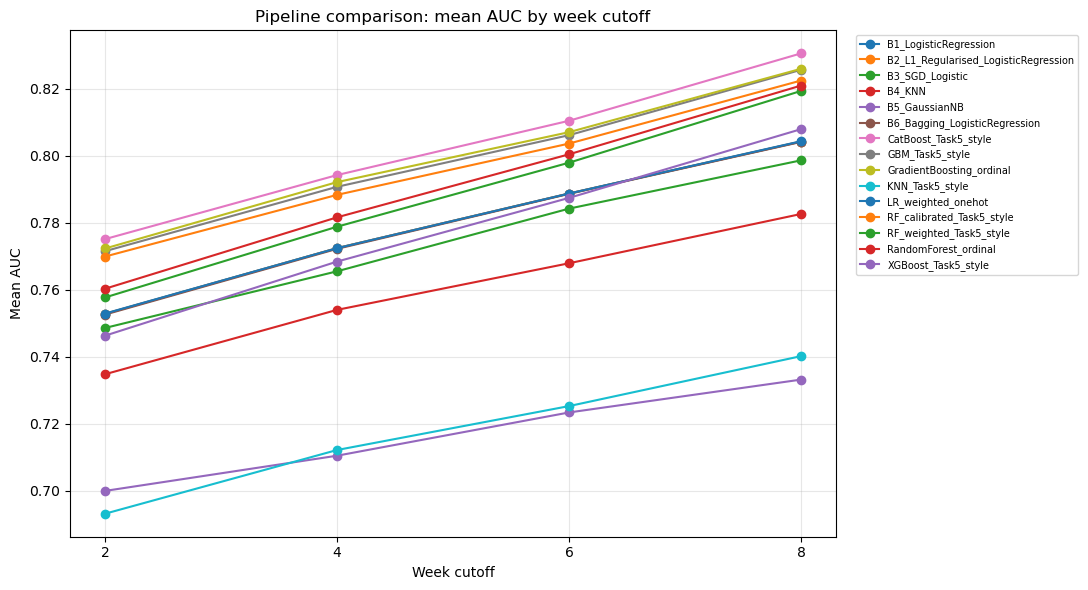

Saved: results/task6_pipeline_auc_by_week.png


In [18]:
# Figure 1: AUC by week for all CV models
plot_df = all_cv_results.copy()

plt.figure(figsize=(11, 6))
for model_name, group in plot_df.groupby("pipeline_id"):
    group = group.sort_values("week_cutoff")
    plt.plot(group["week_cutoff"], group["auc_mean"], marker="o", label=model_name)

plt.xlabel("Week cutoff")
plt.ylabel("Mean AUC")
plt.title("Pipeline comparison: mean AUC by week cutoff")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("results/task6_pipeline_auc_by_week.png", dpi=200)
plt.show()

print("Saved: results/task6_pipeline_auc_by_week.png")


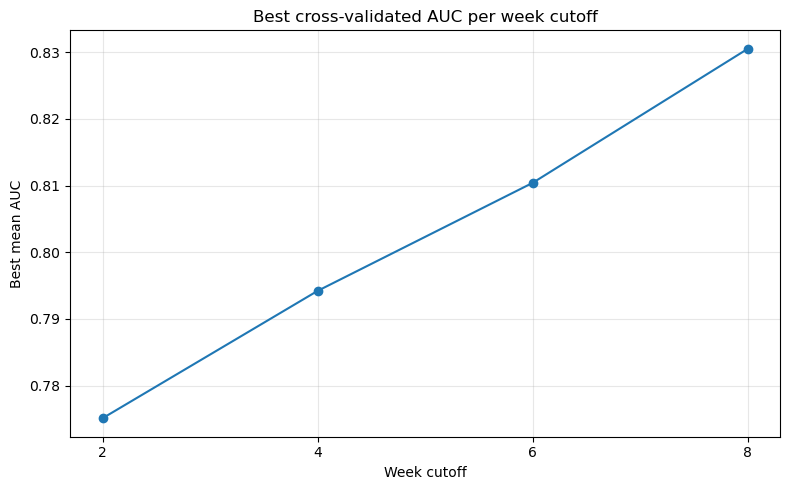

Saved: results/task6_best_auc_per_week.png


In [19]:
# Figure 2: Best model per week
best_plot = best_pipeline_per_week.sort_values("week_cutoff")

plt.figure(figsize=(8, 5))
plt.plot(best_plot["week_cutoff"], best_plot["auc_mean"], marker="o")
plt.xlabel("Week cutoff")
plt.ylabel("Best mean AUC")
plt.title("Best cross-validated AUC per week cutoff")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/task6_best_auc_per_week.png", dpi=200)
plt.show()

print("Saved: results/task6_best_auc_per_week.png")


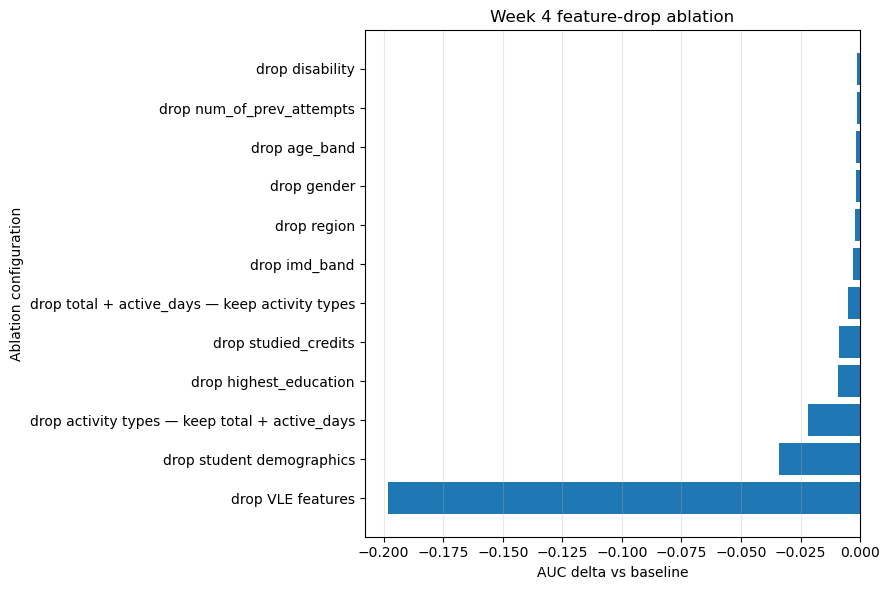

Saved: results/task6_week4_feature_ablation.png


In [20]:
# Figure 3: Week 4 feature-drop ablation
w4 = feature_ablation[
    (feature_ablation["week_cutoff"] == 4) &
    (feature_ablation["configuration"] != "baseline (all features)")
].sort_values("auc_delta")

plt.figure(figsize=(9, 6))
plt.barh(w4["configuration"], w4["auc_delta"])
plt.xlabel("AUC delta vs baseline")
plt.ylabel("Ablation configuration")
plt.title("Week 4 feature-drop ablation")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("results/task6_week4_feature_ablation.png", dpi=200)
plt.show()

print("Saved: results/task6_week4_feature_ablation.png")


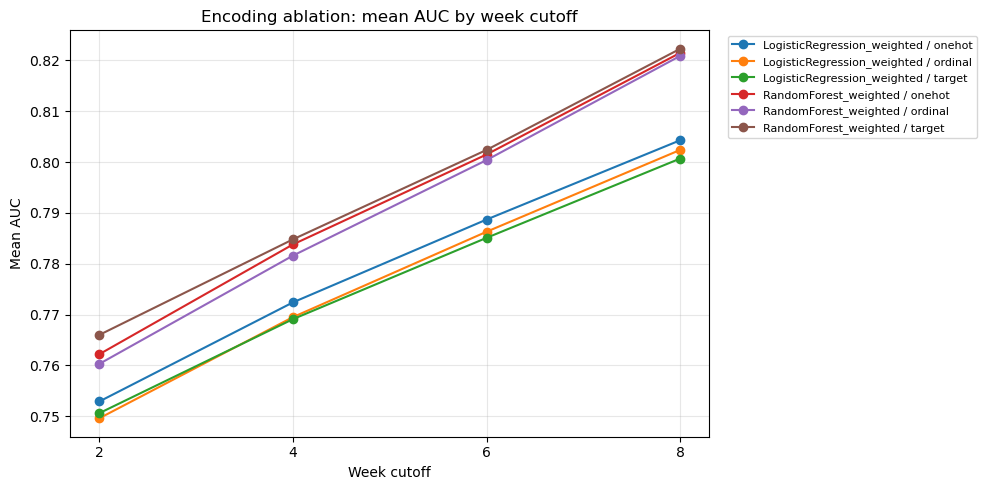

Saved: results/task6_encoding_ablation.png


In [21]:
# Figure 4: Encoding ablation
enc_plot = encoding_ablation.copy()

plt.figure(figsize=(10, 5))
for config, group in enc_plot.groupby("configuration"):
    group = group.sort_values("week_cutoff")
    plt.plot(group["week_cutoff"], group["auc_mean"], marker="o", label=config)

plt.xlabel("Week cutoff")
plt.ylabel("Mean AUC")
plt.title("Encoding ablation: mean AUC by week cutoff")
plt.xticks([2, 4, 6, 8])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("results/task6_encoding_ablation.png", dpi=200)
plt.show()

print("Saved: results/task6_encoding_ablation.png")


## 13. Written interpretation

In [22]:
best_overall = all_cv_results.sort_values(["auc_mean", "f1_mean"], ascending=False).iloc[0]

largest_drop = (
    feature_ablation[feature_ablation["configuration"] != "baseline (all features)"]
    .sort_values("auc_delta")
    .iloc[0]
)

text = f'''
Cross-validation was performed using {CV_FOLDS}-fold stratified cross-validation across the week 2, 4, 6, and 8 feature tables. 
The strongest overall pipeline was {best_overall["pipeline_id"]} at week {best_overall["week_cutoff"]}, with a mean AUC of {best_overall["auc_mean"]:.4f} and a mean F1 score of {best_overall["f1_mean"]:.4f}. 
The results generally improved as the week cutoff increased, which suggests that additional student activity data improves early at-risk prediction.

The feature-drop ablation study showed that the largest AUC decrease occurred for "{largest_drop["configuration"]}" at week {largest_drop["week_cutoff"]}, with an AUC delta of {largest_drop["auc_delta"]:+.4f}. 
This indicates that the removed feature group carries important predictive information. 
In particular, decreases after removing VLE engagement features show that online activity behaviour is a major contributor to the prediction task.

The encoding ablation compared ordinal, one-hot, and target encoding where available. 
One-hot encoding is especially important for linear models because it avoids imposing artificial numerical order on categorical variables. 
Tree-based models were generally less sensitive to the encoding choice, although the final choice should still be based on the cross-validated AUC and F1 results.
'''

print(text)



Cross-validation was performed using 5-fold stratified cross-validation across the week 2, 4, 6, and 8 feature tables. 
The strongest overall pipeline was CatBoost_Task5_style at week 8, with a mean AUC of 0.8305 and a mean F1 score of 0.7601. 
The results generally improved as the week cutoff increased, which suggests that additional student activity data improves early at-risk prediction.

The feature-drop ablation study showed that the largest AUC decrease occurred for "drop VLE features" at week 8, with an AUC delta of -0.2374. 
This indicates that the removed feature group carries important predictive information. 
In particular, decreases after removing VLE engagement features show that online activity behaviour is a major contributor to the prediction task.

The encoding ablation compared ordinal, one-hot, and target encoding where available. 
One-hot encoding is especially important for linear models because it avoids imposing artificial numerical order on categorical variable